In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Display options (optional but useful)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

# Load dataset (case-safe for macOS/Linux)
DATA_DIR = Path('.')

def read_csv_case_safe(filename: str) -> pd.DataFrame:
    path = DATA_DIR / filename
    if path.exists():
        return pd.read_csv(path)
    # try common alternative casing
    alt = {
        'train.csv': 'Train.csv',
        'test.csv': 'Test.csv',
        'variabledefinitions.csv': 'VariableDefinitions.csv',
        'samplesubmission.csv': 'SampleSubmission.csv',
    }.get(filename.lower())
    if alt is not None and (DATA_DIR / alt).exists():
        return pd.read_csv(DATA_DIR / alt)
    # last resort: case-insensitive search
    candidates = list(DATA_DIR.glob(filename)) + list(DATA_DIR.glob(filename.lower()))
    if candidates:
        return pd.read_csv(candidates[0])
    raise FileNotFoundError(f"Could not find {filename} in {DATA_DIR.resolve()}")

train_dataset = read_csv_case_safe('Train.csv')
test_dataset = read_csv_case_safe('Test.csv')

In [2]:
train_dataset.head()

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,7000.0,14.0,Never had,Have now,Yes,Yes,Male,"Yes, sometimes",No,Never had,"Yes, always",Yes,Yes,No,Yes,Yes,Yes,Yes,Never had,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,NaN,15.0,Have now,Have now,NaN,Yes,Male,"Yes, sometimes",Yes,Never had,"Yes, always",No,Yes,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,13000.0,5.0,NaN,Never had,Yes,Yes,Male,"Yes, sometimes",Yes,Never had,No,Don?t know / doesn?t apply,Yes,No,NaN,Yes,Yes,No,Never had,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,30000.0,1.0,NaN,Have now,No,Yes,Female,"Yes, sometimes",No,Never had,No,No,Yes,No,NaN,Yes,No,No,Never had,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,1800.0,3.0,Never had,NaN,NaN,No,Female,"Yes, sometimes",Yes,Never had,No,Yes,Yes,No,No,NaN,NaN,NaN,NaN,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low


### Data Analysis

In [3]:
# Basic dataset overview
print('Train shape:', train_dataset.shape)
print('Test shape :', test_dataset.shape)

print('\nTrain columns:', len(train_dataset.columns))
print('Test columns :', len(test_dataset.columns))

# Check target presence
target_col = 'Target'
print('\nTarget in train?', target_col in train_dataset.columns)
print('Target in test? ', target_col in test_dataset.columns)

Train shape: (9618, 39)
Test shape : (2405, 38)

Train columns: 39
Test columns : 38

Target in train? True
Target in test?  False


In [4]:
# Schema / types
display(train_dataset.dtypes.to_frame('dtype').head(50))

# Quick check: columns mismatch between train and test (excluding Target)
train_features = [c for c in train_dataset.columns if c != 'Target']
test_features = list(test_dataset.columns)

missing_in_test = sorted(set(train_features) - set(test_features))
extra_in_test = sorted(set(test_features) - set(train_features))

print('Missing in test (should be empty):', missing_in_test)
print('Extra in test (should be empty):', extra_in_test)

,dtype
ID,object
country,object
owner_age,float64
attitude_stable_business_environment,object
attitude_worried_shutdown,object
compliance_income_tax,object
perception_insurance_doesnt_cover_losses,object
perception_cannot_afford_insurance,object
personal_income,float64
business_expenses,float64


Missing in test (should be empty): []
Extra in test (should be empty): []


In [5]:
# Missing values overview (train + test)
def missing_report(df: pd.DataFrame, name: str, top_n: int = 25) -> pd.DataFrame:
    miss = df.isna().mean().sort_values(ascending=False)
    out = pd.DataFrame({
        'missing_rate': miss,
        'missing_count': df.isna().sum(),
        'dtype': df.dtypes.astype(str),
    })
    out.index.name = 'feature'
    print(f"\nTop missing features in {name} (top {top_n}):")
    return out.head(top_n)

display(missing_report(train_dataset, 'train', top_n=25))
display(missing_report(test_dataset, 'test', top_n=25))


Top missing features in train (top 25):


,missing_rate,missing_count,dtype
feature,,,
ID,0.000000,0,object
Target,0.000000,0,object
attitude_more_successful_next_year,0.271574,2612,object
attitude_satisfied_with_achievement,0.202329,1946,object
attitude_stable_business_environment,0.000208,2,object
attitude_worried_shutdown,0.000208,2,object
business_age_months,0.427428,4111,float64
business_age_years,0.026201,252,float64
business_expenses,0.023810,229,float64



Top missing features in test (top 25):


,missing_rate,missing_count,dtype
feature,,,
ID,0.000000,0,object
attitude_more_successful_next_year,0.271518,653,object
attitude_satisfied_with_achievement,0.202079,486,object
attitude_stable_business_environment,0.000000,0,object
attitude_worried_shutdown,0.000000,0,object
business_age_months,0.429522,1033,float64
business_age_years,0.024532,59,float64
business_expenses,0.029106,70,float64
business_turnover,0.029106,70,float64


In [6]:
# Duplicates & basic ID checks
id_col = 'ID'
print('ID in train?', id_col in train_dataset.columns)
print('ID in test? ', id_col in test_dataset.columns)

if id_col in train_dataset.columns:
    print('Train duplicate IDs:', train_dataset[id_col].duplicated().sum())
if id_col in test_dataset.columns:
    print('Test duplicate IDs :', test_dataset[id_col].duplicated().sum())

# Duplicate rows (excluding Target)
train_dupe_rows = train_dataset.drop(columns=['Target'], errors='ignore').duplicated().sum()
test_dupe_rows = test_dataset.duplicated().sum()
print('Train duplicate rows (features-only):', train_dupe_rows)
print('Test duplicate rows:', test_dupe_rows)

ID in train? True
ID in test?  True
Train duplicate IDs: 0
Test duplicate IDs : 0
Train duplicate rows (features-only): 0
Test duplicate rows: 0


In [7]:
# Target distribution (class balance)
if 'Target' in train_dataset.columns:
    target_counts = train_dataset['Target'].value_counts(dropna=False)
    target_rates = train_dataset['Target'].value_counts(normalize=True, dropna=False).round(4)
    display(pd.DataFrame({'count': target_counts, 'rate': target_rates}))
else:
    print('No Target column found in training data.')

,count,rate
Target,,
Low,6280,0.6529
Medium,2868,0.2982
High,470,0.0489


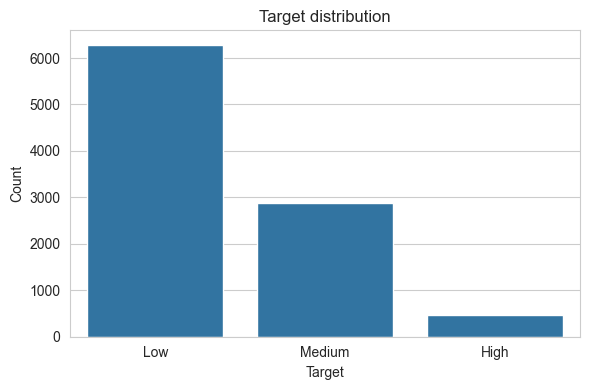

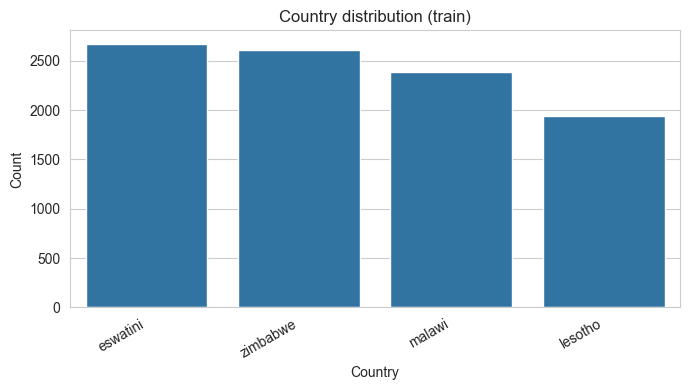

In [8]:
# Quick plots: target distribution + country distribution
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

if 'Target' in train_dataset.columns:
    plt.figure(figsize=(6, 4))
    ax = sns.countplot(data=train_dataset, x='Target', order=train_dataset['Target'].value_counts().index)
    ax.set_title('Target distribution')
    ax.set_xlabel('Target')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()

if 'country' in train_dataset.columns:
    plt.figure(figsize=(7, 4))
    ax = sns.countplot(data=train_dataset, x='country', order=train_dataset['country'].value_counts().index)
    ax.set_title('Country distribution (train)')
    ax.set_xlabel('Country')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

In [9]:
# Numeric summary + outlier hints
numeric_cols = train_dataset.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', len(numeric_cols))
display(train_dataset[numeric_cols].describe().T)

# Look at extreme values for a few key financial columns (if present)
for col in ['personal_income', 'business_expenses', 'business_turnover']:
    if col in train_dataset.columns:
        s = train_dataset[col]
        print(f"\n{col}: min={s.min(skipna=True)}  p1={s.quantile(0.01)}  median={s.median(skipna=True)}  p99={s.quantile(0.99)}  max={s.max(skipna=True)}")

Numeric columns: 6


,count,mean,std,min,25%,50%,75%,max
owner_age,9618.0,4.170534e+01,1.331401e+01,18.0,32.0,40.0,50.0,103.0
personal_income,9509.0,2.627345e+05,2.566268e+06,0.0,300.0,2000.0,25000.0,150000000.0
business_expenses,9389.0,4.583838e+05,6.184746e+06,0.0,700.0,3000.0,25000.0,500000000.0
business_turnover,9402.0,1.348210e+06,8.804741e+06,0.0,1500.0,6000.0,50000.0,420000000.0
business_age_years,9366.0,7.030536e+00,7.650349e+00,0.0,2.0,4.0,10.0,60.0
business_age_months,5507.0,3.636281e+00,3.386488e+00,0.0,0.0,3.0,6.0,11.0



personal_income: min=0.0  p1=20.0  median=2000.0  p99=3129200.000000001  max=150000000.0

business_expenses: min=0.0  p1=40.0  median=3000.0  p99=8019200.0000001285  max=500000000.0

business_turnover: min=0.0  p1=97.0  median=6000.0  p99=24994999.999999892  max=420000000.0


In [10]:
# Categorical feature scan: top values + cardinality
categorical_cols = [c for c in train_dataset.columns if c not in numeric_cols + ['Target']]
print('Categorical columns:', len(categorical_cols))

cardinality = train_dataset[categorical_cols].nunique(dropna=False).sort_values(ascending=False)
display(cardinality.to_frame('n_unique').head(25))

# Show the most common values for a few high-signal columns
for col in ['owner_sex', 'has_mobile_money', 'has_insurance', 'keeps_financial_records']:
    if col in train_dataset.columns:
        print(f"\nValue counts: {col}")
        display(train_dataset[col].value_counts(dropna=False).head(10))

Categorical columns: 32


,n_unique
ID,9618
has_loan_account,7
uses_friends_family_savings,7
medical_insurance,7
has_internet_banking,7
uses_informal_lender,7
perception_insurance_companies_dont_insure_businesses_like_yours,6
has_mobile_money,6
funeral_insurance,6
has_debit_card,6



Value counts: owner_sex


owner_sex
Female    4303
Male      3371
NaN       1944
Name: count, dtype: int64


Value counts: has_mobile_money


has_mobile_money
Have now                           4876
NaN                                2751
Never had                          1842
Used to have but don't have now      82
Used to have but don’t have now      61
Don't know                            6
Name: count, dtype: int64


Value counts: has_insurance


has_insurance
No     7375
NaN    1956
Yes     287
Name: count, dtype: int64


Value counts: keeps_financial_records


keeps_financial_records
No                3334
NaN               1949
Yes, sometimes    1671
Yes, always       1525
Yes               1139
Name: count, dtype: int64

In [11]:
# Relationship check: simple target vs. a few features
if 'Target' in train_dataset.columns:
    cols_to_check = ['country', 'keeps_financial_records', 'has_insurance', 'current_problem_cash_flow']
    for col in cols_to_check:
        if col in train_dataset.columns:
            ct = pd.crosstab(train_dataset[col], train_dataset['Target'], normalize='index').round(3)
            print(f"\nP(Target | {col})")
            display(ct)


P(Target | country)


Target,High,Low,Medium
country,,,
eswatini,0.115,0.514,0.371
lesotho,0.003,0.604,0.393
malawi,0.040,0.812,0.147
zimbabwe,0.023,0.686,0.291



P(Target | keeps_financial_records)


Target,High,Low,Medium
keeps_financial_records,,,
No,0.020,0.779,0.201
Yes,0.071,0.739,0.190
"Yes, always",0.153,0.445,0.402
"Yes, sometimes",0.048,0.591,0.360



P(Target | has_insurance)


Target,High,Low,Medium
has_insurance,,,
No,0.049,0.691,0.260
Yes,0.359,0.000,0.641



P(Target | current_problem_cash_flow)


Target,High,Low,Medium
current_problem_cash_flow,,,
0,0.099,0.537,0.364
No,0.044,0.812,0.144
Yes,0.076,0.596,0.328


In [12]:
# (Optional) Load variable definitions for easier interpretation
try:
    var_defs = read_csv_case_safe('VariableDefinitions.csv')
    display(var_defs.head(30))
except Exception as e:
    print('Could not load VariableDefinitions.csv:', e)

,VARIABLE_NAME,VARIABLE_DESCRIPTION
0,ID,Unique identifier for each business record
1,country,Country where the business is located (Eswatin...
2,owner_age,Age of the business owner in years
3,attitude_stable_business_environment,Owner attitude: Country will have a stable bus...
4,attitude_worried_shutdown,Owner attitude: Worried that the business will...
5,compliance_income_tax,Business complies with or acts in accordance w...
6,perception_insurance_doesnt_cover_losses,Owner perception: Insurance does not cover the...
7,perception_cannot_afford_insurance,Owner perception: Cannot afford insurance paym...
8,personal_income,Total monthly personal income of the owner bef...
9,business_expenses,Approximate monthly or annual expenses of the ...


### Data Processing Model 

In [13]:
# Preprocessing pipeline: categorical -> most_frequent, numeric -> mean
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Features / target
TARGET = 'Target'
DROP_COLS = ['ID']  # safe to drop ID for modeling
X = train_dataset.drop(columns=[TARGET], errors='ignore').drop(columns=DROP_COLS, errors='ignore')
y = train_dataset[TARGET] if TARGET in train_dataset.columns else None

# Recompute column lists (robust even if earlier cells changed)
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Example usage (fit on train split only to avoid leakage)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
print('Processed train shape:', X_train_processed.shape)
print('Processed valid shape:', X_valid_processed.shape)

# If you need feature names after encoding:
try:
    feature_names = preprocessor.get_feature_names_out()
    print('Feature names length:', len(feature_names))
except Exception as e:
    print('Could not extract feature names:', e)

Numeric features: 6
Categorical features: 31
Processed train shape: (7694, 125)
Processed valid shape: (1924, 125)
Feature names length: 125


### Imputation Strategy Selection (Feature-by-Feature + CV Bake-off)
This section analyzes each feature’s missingness patterns (numeric vs categorical), checks whether missingness is informative for the target, and then runs a small cross-validated bake-off to choose the best imputation strategy.

**Why:** mean/mode is a good baseline, but better choices often depend on skew (numeric), “not applicable” semantics (categorical), and whether missingness itself correlates with the label.

In [14]:
# Feature profiling for imputation decisions
from typing import Dict, List, Tuple
from scipy.stats import chi2_contingency

assert 'train_dataset' in globals(), 'Run Cell 1 (data loading) first.'
assert 'TARGET' in globals(), 'Run the preprocessing cell (Cell 16) first to define TARGET.'

target_col = TARGET
id_col = 'ID'

df = train_dataset.copy()
assert target_col in df.columns, f"Expected target column '{target_col}' in train_dataset."

X_raw = df.drop(columns=[target_col], errors='ignore').drop(columns=[id_col], errors='ignore')
y_raw = df[target_col].astype(str)

def _target_shift_for_missing(mask_missing: pd.Series, y: pd.Series) -> float:
    """Total variation distance between P(y|missing) and P(y|not missing). Range [0, 1]."""
    if mask_missing.sum() < 25 or (~mask_missing).sum() < 25:
        return np.nan
    p_m = y[mask_missing].value_counts(normalize=True)
    p_nm = y[~mask_missing].value_counts(normalize=True)
    idx = sorted(set(p_m.index) | set(p_nm.index))
    p_m = p_m.reindex(idx, fill_value=0.0)
    p_nm = p_nm.reindex(idx, fill_value=0.0)
    return 0.5 * float(np.abs(p_m.values - p_nm.values).sum())

def _chisq_pvalue_for_missing(mask_missing: pd.Series, y: pd.Series) -> float:
    """Chi-square p-value for association between missingness and target."""
    if mask_missing.sum() < 5 or (~mask_missing).sum() < 5:
        return np.nan
    tab = pd.crosstab(mask_missing.astype(int), y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    try:
        _, p, _, _ = chi2_contingency(tab.values)
        return float(p)
    except Exception:
        return np.nan

numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]

profile_rows: List[Dict] = []
for col in X_raw.columns:
    s = X_raw[col]
    miss_rate = float(s.isna().mean())
    miss_cnt = int(s.isna().sum())
    nunique = int(s.nunique(dropna=True))
    miss_shift = _target_shift_for_missing(s.isna(), y_raw)
    miss_p = _chisq_pvalue_for_missing(s.isna(), y_raw)
    row = {
        'feature': col,
        'dtype': str(s.dtype),
        'is_numeric': col in numeric_cols,
        'missing_rate': miss_rate,
        'missing_count': miss_cnt,
        'n_unique': nunique,
        'missing_target_shift_TVD': miss_shift,
        'missing_target_chisq_p': miss_p,
    }
    if col in numeric_cols:
        ss = s.dropna()
        row['skew'] = float(ss.skew()) if len(ss) > 0 else np.nan
        row['kurtosis'] = float(ss.kurtosis()) if len(ss) > 0 else np.nan
        row['p01'] = float(ss.quantile(0.01)) if len(ss) > 0 else np.nan
        row['median'] = float(ss.median()) if len(ss) > 0 else np.nan
        row['p99'] = float(ss.quantile(0.99)) if len(ss) > 0 else np.nan
    else:
        vc = s.value_counts(dropna=False).head(3)
        row['top_values'] = ', '.join([f"{idx}:{int(val)}" for idx, val in vc.items()])
    profile_rows.append(row)

feature_profile = pd.DataFrame(profile_rows).sort_values(['missing_rate', 'missing_target_shift_TVD'], ascending=[False, False])
display(feature_profile.head(30))

print('Numeric cols:', len(numeric_cols), 'Categorical cols:', len(categorical_cols))

,feature,dtype,is_numeric,missing_rate,missing_count,n_unique,missing_target_shift_TVD,missing_target_chisq_p,top_values,skew,kurtosis,p01,median,p99
36,uses_informal_lender,object,False,0.466729,4489,6,0.171665,9.467428e-71,"nan:4489, Never had:2864, Used to have but don...",NaN,NaN,NaN,NaN,NaN
35,uses_friends_family_savings,object,False,0.466625,4488,6,0.171943,6.020469e-71,"nan:4488, Never had:2895, Used to have but don...",NaN,NaN,NaN,NaN,NaN
34,motivation_make_more_money,object,False,0.446143,4291,2,0.147596,1.001263e-68,"nan:4291, Yes:3462, No:1865",NaN,NaN,NaN,NaN,NaN
32,medical_insurance,object,False,0.435434,4188,6,0.156267,5.336169e-80,"Never had:4794, nan:4188, Have now:404",NaN,NaN,NaN,NaN,NaN
33,funeral_insurance,object,False,0.435434,4188,5,0.156267,5.336169e-80,"nan:4188, Never had:3615, Have now:1608",NaN,NaN,NaN,NaN,NaN
31,business_age_months,float64,True,0.427428,4111,12,0.102706,2.441086e-34,NaN,0.682402,-0.635957,0.0,3.0,11.0
30,future_risk_theft_stock,object,False,0.426284,4100,2,0.187508,3.704116e-85,"nan:4100, No:3191, Yes:2327",NaN,NaN,NaN,NaN,NaN
28,has_internet_banking,object,False,0.416199,4003,6,0.094714,1.139917e-48,"Never had:4713, nan:4003, Have now:550",NaN,NaN,NaN,NaN,NaN
29,has_debit_card,object,False,0.416199,4003,5,0.094714,1.139917e-48,"nan:4003, Never had:3864, Have now:1438",NaN,NaN,NaN,NaN,NaN
27,has_loan_account,object,False,0.415783,3999,6,0.094395,1.844679e-48,"Never had:4501, nan:3999, Used to have but don...",NaN,NaN,NaN,NaN,NaN


Numeric cols: 6 Categorical cols: 31


In [15]:
# Recommended imputation heuristic (feature-by-feature guidance)
fp = feature_profile.copy()

# Heuristic rules of thumb:
# - Numeric: if |skew| >= 1 -> median; else mean. If missingness is informative (high TVD) -> add missing indicator.
# - Categorical: if missingness is informative or missing_rate is high -> treat missing as explicit category; else most_frequent.

fp['impute_numeric'] = None
fp.loc[fp['is_numeric'] == True, 'impute_numeric'] = np.where(
    fp.loc[fp['is_numeric'] == True, 'skew'].abs().fillna(0) >= 1.0,
    'median',
    'mean',
 )

fp['add_missing_indicator'] = (fp['missing_target_shift_TVD'].fillna(0) >= 0.05)

fp['impute_categorical'] = None
mask_cat = fp['is_numeric'] == False
fp.loc[mask_cat, 'impute_categorical'] = np.where(
    (fp.loc[mask_cat, 'missing_rate'] >= 0.15) | (fp.loc[mask_cat, 'missing_target_shift_TVD'].fillna(0) >= 0.05),
    'explicit_Missing',
    'most_frequent',
 )

# Show the most actionable subset: features with missingness and/or informative missingness
actionable = fp[(fp['missing_rate'] > 0) | (fp['missing_target_shift_TVD'].fillna(0) >= 0.05)]
actionable = actionable.sort_values(['missing_target_shift_TVD', 'missing_rate'], ascending=[False, False])
display(actionable[['feature','dtype','is_numeric','missing_rate','missing_target_shift_TVD','skew','impute_numeric','impute_categorical','add_missing_indicator']].head(40))

print('Heuristic notes:')
print('- TVD >= 0.05 suggests missingness is label-informative; consider missing indicators or explicit Missing category.')
print('- |skew| >= 1 suggests median is often safer than mean for numeric imputation.')

,feature,dtype,is_numeric,missing_rate,missing_target_shift_TVD,skew,impute_numeric,impute_categorical,add_missing_indicator
11,motor_vehicle_insurance,object,False,0.233313,0.270161,NaN,None,explicit_Missing,True
23,covid_essential_service,object,False,0.248492,0.212386,NaN,None,explicit_Missing,True
30,future_risk_theft_stock,object,False,0.426284,0.187508,NaN,None,explicit_Missing,True
35,uses_friends_family_savings,object,False,0.466625,0.171943,NaN,None,explicit_Missing,True
36,uses_informal_lender,object,False,0.466729,0.171665,NaN,None,explicit_Missing,True
10,business_age_years,float64,True,0.026201,0.164869,2.156752,median,None,True
32,medical_insurance,object,False,0.435434,0.156267,NaN,None,explicit_Missing,True
33,funeral_insurance,object,False,0.435434,0.156267,NaN,None,explicit_Missing,True
34,motivation_make_more_money,object,False,0.446143,0.147596,NaN,None,explicit_Missing,True
19,keeps_financial_records,object,False,0.202641,0.119575,NaN,None,explicit_Missing,True


Heuristic notes:
- TVD >= 0.05 suggests missingness is label-informative; consider missing indicators or explicit Missing category.
- |skew| >= 1 suggests median is often safer than mean for numeric imputation.


In [16]:
# Cross-validated bake-off of imputation strategies (macro-F1)
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb

assert 'X' in globals() and 'y' in globals(), 'Run preprocessing cell (Cell 16) to define X and y.'
assert y is not None, 'y is None; ensure Train.csv includes Target.'

# Label encode once for stable metric computation
le_cv = LabelEncoder()
y_enc_full = le_cv.fit_transform(y.astype(str))
class_names_cv = list(le_cv.classes_)
n_classes_cv = len(class_names_cv)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

def make_preprocessor(strategy_name: str) -> ColumnTransformer:
    """Build a preprocessor for a named imputation strategy."""
    if strategy_name == 'mean+mode':
        num_imp = SimpleImputer(strategy='mean')
        cat_imp = SimpleImputer(strategy='most_frequent')
    elif strategy_name == 'median+mode':
        num_imp = SimpleImputer(strategy='median')
        cat_imp = SimpleImputer(strategy='most_frequent')
    elif strategy_name == 'mean+Missing':
        num_imp = SimpleImputer(strategy='mean')
        cat_imp = SimpleImputer(strategy='constant', fill_value='Missing')
    elif strategy_name == 'median+Missing':
        num_imp = SimpleImputer(strategy='median')
        cat_imp = SimpleImputer(strategy='constant', fill_value='Missing')
    elif strategy_name == 'median+Missing+ind':
        num_imp = SimpleImputer(strategy='median', add_indicator=True)
        cat_imp = SimpleImputer(strategy='constant', fill_value='Missing')
    else:
        raise ValueError(f'Unknown strategy: {strategy_name}')

    numeric_transformer = Pipeline(steps=[('imputer', num_imp)])
    categorical_transformer = Pipeline(steps=[
        ('imputer', cat_imp),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

# Keep the model small-ish so CV runs quickly
def make_model():
    return xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=n_classes_cv,
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=1.0,
        tree_method='hist',
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss',
    )

strategies = [
    'mean+mode',
    'median+mode',
    'mean+Missing',
    'median+Missing',
    'median+Missing+ind',
 ]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rows = []

for strat in strategies:
    fold_scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(X, y_enc_full), start=1):
        X_tr = X.iloc[tr_idx]
        y_tr = y_enc_full[tr_idx]
        X_va = X.iloc[va_idx]
        y_va = y_enc_full[va_idx]

        # Balanced sample weights per fold
        classes_fold = np.unique(y_tr)
        w = compute_class_weight(class_weight='balanced', classes=classes_fold, y=y_tr)
        w_map = dict(zip(classes_fold, w))
        sw = np.array([w_map[c] for c in y_tr])

        pre = make_preprocessor(strat)
        model = make_model()
        pipe = Pipeline(steps=[('preprocess', pre), ('model', model)])
        pipe.fit(X_tr, y_tr, model__sample_weight=sw)
        pred = pipe.predict(X_va)
        f1m = f1_score(y_va, pred, average='macro')
        fold_scores.append(f1m)
    rows.append({
        'strategy': strat,
        'f1_macro_mean': float(np.mean(fold_scores)),
        'f1_macro_std': float(np.std(fold_scores)),
    })

imputation_bakeoff = pd.DataFrame(rows).sort_values('f1_macro_mean', ascending=False)
display(imputation_bakeoff)

best_strategy = imputation_bakeoff.iloc[0]['strategy']
print(f"Best strategy by CV macro-F1: {best_strategy}")

# Optional: build a recommended preprocessor to reuse downstream
preprocessor_best = make_preprocessor(best_strategy)

,strategy,f1_macro_mean,f1_macro_std
3,median+Missing,0.800312,0.009682
4,median+Missing+ind,0.797272,0.011239
2,mean+Missing,0.797131,0.010857
1,median+mode,0.792781,0.013679
0,mean+mode,0.792329,0.011758


Best strategy by CV macro-F1: median+Missing


In [17]:
# Feature Engineering: Log transforms and Ratios
def engineer_features(df):
    df_eng = df.copy()
    
    # Log transforms for skewed financial columns
    for col in ['personal_income', 'business_turnover', 'business_expenses']:
        if col in df_eng.columns:
            # Use log1p to handle zeros safely
            df_eng[f'log_{col}'] = np.log1p(df_eng[col])
            
    # Ratio features
    # expenses / turnover
    if 'business_expenses' in df_eng.columns and 'business_turnover' in df_eng.columns:
        # Add small epsilon to avoid division by zero
        df_eng['ratio_expenses_turnover'] = df_eng['business_expenses'] / (df_eng['business_turnover'] + 1)
        
    # turnover / income
    if 'business_turnover' in df_eng.columns and 'personal_income' in df_eng.columns:
        df_eng['ratio_turnover_income'] = df_eng['business_turnover'] / (df_eng['personal_income'] + 1)
        
    return df_eng

print("Applying feature engineering...")
# Apply to global datasets if not already applied
# Check one new column to see if we need to run
if 'log_personal_income' not in train_dataset.columns:
    train_dataset = engineer_features(train_dataset)
    test_dataset = engineer_features(test_dataset)
    print("Feature engineering applied to train_dataset and test_dataset.")
else:
    print("Feature engineering already applied.")

# Re-define X and y from the updated train_dataset
X = train_dataset.drop(columns=[TARGET], errors='ignore').drop(columns=DROP_COLS, errors='ignore')
y = train_dataset[TARGET] if TARGET in train_dataset.columns else None

# Re-detect feature types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]
print(f'Updated feature counts - Numeric: {len(numeric_features)}, Categorical: {len(categorical_features)}')

# Re-create preprocessor with new feature lists
# We need to call make_preprocessor again because it captures the global numeric_features/categorical_features
if 'best_strategy' in globals():
    preprocessor = make_preprocessor(best_strategy)
    print(f"Re-created preprocessor with strategy: {best_strategy}")
else:
    # Fallback if bake-off wasn't run
    print("Warning: best_strategy not found. Using default mean+mode.")
    preprocessor = make_preprocessor('mean+mode')

# Re-create train/valid split
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
 )

# Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
print('Processed train shape (engineered):', X_train_processed.shape)
print('Processed valid shape (engineered):', X_valid_processed.shape)

Applying feature engineering...
Feature engineering applied to train_dataset and test_dataset.
Updated feature counts - Numeric: 11, Categorical: 31
Re-created preprocessor with strategy: median+Missing
Processed train shape (engineered): (7694, 160)
Processed valid shape (engineered): (1924, 160)


### Feature engineering and Selection

In [18]:
# Feature Selection Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# 1. Prepare Data with Feature Names
try:
    feature_names = preprocessor.get_feature_names_out()
except AttributeError:
    # Fallback if get_feature_names_out is not available or fails
    feature_names = [f"feat_{i}" for i in range(X_train_processed.shape[1])]

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_valid_df = pd.DataFrame(X_valid_processed, columns=feature_names)

# Encode Target Ordinally for Correlation Analysis
# Assuming Low < Medium < High based on "Financial Health Index"
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
# If values are different, we might need to adjust. Let's check unique values first if possible, 
# but for now we'll try this mapping. If it fails (e.g. keys don't match), we'll fall back to LabelEncoder.

y_train_mapped = y_train.map(target_mapping)
if y_train_mapped.isna().any():
    print("Warning: Custom mapping resulted in NaNs. Falling back to LabelEncoder.")
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_valid_encoded = le.transform(y_valid)
else:
    y_train_encoded = y_train_mapped.values
    y_valid_encoded = y_valid.map(target_mapping).values

print(f"Feature set shape: {X_train_df.shape}")

# 2. Correlation with Target
# Calculate correlation of each feature with the target
correlations = X_train_df.corrwith(pd.Series(y_train_encoded, index=X_train_df.index))
correlations = correlations.abs().sort_values(ascending=False)

print("\nTop 10 Features by Correlation with Target:")
display(correlations.head(10).to_frame('abs_correlation'))

# 3. Feature Importance from Tree-based Model (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train_df, y_train_encoded)

importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

print("\nTop 10 Features by Random Forest Importance:")
display(importances.head(10).to_frame('importance'))

# 4. Permutation Importance
# This is more reliable than impurity-based importance
perm_importance = permutation_importance(rf, X_valid_df, y_valid_encoded, n_repeats=5, random_state=42, n_jobs=-1)
perm_importances_mean = pd.Series(perm_importance.importances_mean, index=feature_names).sort_values(ascending=False)

print("\nTop 10 Features by Permutation Importance (Validation Set):")
display(perm_importances_mean.head(10).to_frame('perm_importance'))

# 5. Multicollinearity Check
# Identify features with high correlation (> 0.95)
corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_collinear = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"\nNumber of highly correlated features (>0.95) to potentially drop: {len(to_drop_collinear)}")
if to_drop_collinear:
    print("Examples:", to_drop_collinear[:5])

# 6. SelectKBest (Mutual Information)
selector = SelectKBest(mutual_info_classif, k=min(40, X_train_df.shape[1]))
selector.fit(X_train_df, y_train_encoded)
selected_indices = selector.get_support(indices=True)
selected_features_kbest = [feature_names[i] for i in selected_indices]

print(f"\nTop {len(selected_features_kbest)} features selected by Mutual Information:")
print(selected_features_kbest)

# Summary of Feature Selection
# Combine top features from different methods
top_n = 40
top_corr = set(correlations.head(top_n).index)
top_rf = set(importances.head(top_n).index)
top_perm = set(perm_importances_mean.head(top_n).index)

# Intersection of methods (robust features)
robust_features = top_corr.intersection(top_rf).intersection(top_perm)
print(f"\nNumber of robust features (intersection of Corr, RF, Perm): {len(robust_features)}")
print(list(robust_features))

# Union of methods (broad set)
candidate_features = top_corr.union(top_rf).union(top_perm)
# Remove collinear ones from candidates
final_candidates = [f for f in candidate_features if f not in to_drop_collinear]
print(f"Number of candidate features after removing collinear: {len(final_candidates)}")


Feature set shape: (7694, 160)

Top 10 Features by Correlation with Target:


,abs_correlation
funeral_insurance_Have now,0.621168
has_credit_card_Have now,0.333878
medical_insurance_Have now,0.309624
has_loan_account_Have now,0.299841
has_insurance_Yes,0.294409
funeral_insurance_Never had,0.272043
motor_vehicle_insurance_Have now,0.268308
"keeps_financial_records_Yes, always",0.239107
motor_vehicle_insurance_Missing,0.231518
compliance_income_tax_Yes,0.228918



Top 10 Features by Random Forest Importance:


,importance
funeral_insurance_Have now,0.084050
funeral_insurance_Never had,0.043961
has_loan_account_Have now,0.039241
has_credit_card_Have now,0.032194
log_business_turnover,0.031624
personal_income,0.031536
business_turnover,0.030470
ratio_turnover_income,0.028800
log_personal_income,0.028082
ratio_expenses_turnover,0.027707



Top 10 Features by Permutation Importance (Validation Set):


,perm_importance
funeral_insurance_Have now,0.131705
has_loan_account_Have now,0.017775
has_credit_card_Have now,0.017152
uses_friends_family_savings_Used to have but don't have now,0.009875
uses_friends_family_savings_Have now,0.009563
has_credit_card_Never had,0.008420
has_insurance_Yes,0.006861
has_loan_account_Never had,0.005717
funeral_insurance_Never had,0.005198
has_insurance_No,0.005094



Number of highly correlated features (>0.95) to potentially drop: 17
Examples: ['attitude_worried_shutdown_Missing', 'motor_vehicle_insurance_Missing', 'has_cellphone_Missing', 'owner_sex_Missing', 'offers_credit_to_customers_Missing']

Top 40 features selected by Mutual Information:
['personal_income', 'business_expenses', 'business_turnover', 'business_age_months', 'log_personal_income', 'log_business_turnover', 'log_business_expenses', 'ratio_turnover_income', 'country_eswatini', 'country_lesotho', 'country_malawi', 'compliance_income_tax_No', 'compliance_income_tax_Yes', 'motor_vehicle_insurance_Have now', 'motor_vehicle_insurance_Missing', 'owner_sex_Missing', 'has_credit_card_Have now', 'keeps_financial_records_Missing', 'keeps_financial_records_No', 'keeps_financial_records_Yes, always', 'perception_insurance_companies_dont_insure_businesses_like_yours_Don?t know / doesn?t apply', 'perception_insurance_companies_dont_insure_businesses_like_yours_No', 'has_insurance_Yes', 'covid

In [19]:
# Final Feature Selection
# Rank features by each method to create a consensus ranking
# We use: Correlation, RF Importance, Permutation Importance, Mutual Information
import re

# Sanitize feature names to avoid LightGBM errors and ensure uniqueness
def sanitize_names(names):
    new_names = []
    seen = set()
    for n in names:
        clean = re.sub(r'[^A-Za-z0-9_]', '_', n)
        # Ensure uniqueness
        if clean in seen:
            i = 1
            while f"{clean}_{i}" in seen:
                i += 1
            clean = f"{clean}_{i}"
        seen.add(clean)
        new_names.append(clean)
    return new_names

# Update DataFrames with sanitized names
X_train_df.columns = sanitize_names(X_train_df.columns)
X_valid_df.columns = sanitize_names(X_valid_df.columns)
feature_names = list(X_train_df.columns)

# Create a DataFrame to store ranks
feature_ranks = pd.DataFrame(index=feature_names)

# Rank 1 = Best
feature_ranks['corr_rank'] = correlations.reindex(feature_names).rank(ascending=False)
feature_ranks['rf_rank'] = importances.reindex(feature_names).rank(ascending=False)
feature_ranks['perm_rank'] = perm_importances_mean.reindex(feature_names).rank(ascending=False)

# Mutual Info scores (we need to get scores for all features)
mi_scores = mutual_info_classif(X_train_df, y_train_encoded, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names)
feature_ranks['mi_rank'] = mi_series.rank(ascending=False)

# Calculate Average Rank
feature_ranks['avg_rank'] = feature_ranks.mean(axis=1)

# Sort by average rank
feature_ranks = feature_ranks.sort_values('avg_rank')

# Filter out highly correlated features
# We iterate through the ranked list and skip features that are highly correlated with already selected ones
selected_features = []
correlated_features_to_exclude = set()

# We want between 20 and 40 features. Let's aim for top 30 initially.
target_count = 40

for feature in feature_ranks.index:
    if feature in correlated_features_to_exclude:
        continue
    
    # Check correlation with already selected features
    is_correlated = False
    for selected in selected_features:
        # Check correlation in the original matrix
        corr_val = abs(X_train_df[feature].corr(X_train_df[selected]))
        if corr_val > 0.95:
            is_correlated = True
            correlated_features_to_exclude.add(feature) # Mark as excluded
            break
    
    if not is_correlated:
        selected_features.append(feature)
    
    if len(selected_features) >= target_count:
        break

print(f"Selected {len(selected_features)} features based on consensus ranking and collinearity filter:")
print(selected_features)

# Create Final Datasets with Selected Features
X_train_final = X_train_df[selected_features]
X_valid_final = X_valid_df[selected_features]

print("\nFinal Train Shape:", X_train_final.shape)
print("Final Valid Shape:", X_valid_final.shape)

# Display top 10 selected features with their ranks
display(feature_ranks.loc[selected_features].head(10))


Selected 40 features based on consensus ranking and collinearity filter:
['funeral_insurance_Have_now', 'medical_insurance_Have_now', 'has_credit_card_Have_now', 'funeral_insurance_Never_had', 'has_insurance_Yes', 'has_loan_account_Have_now', 'compliance_income_tax_Yes', 'funeral_insurance_Missing', 'country_eswatini', 'keeps_financial_records_Yes__always', 'log_personal_income', 'has_credit_card_Never_had', 'has_insurance_No', 'owner_age', 'perception_insurance_important_Yes', 'ratio_turnover_income', 'motor_vehicle_insurance_Have_now', 'motor_vehicle_insurance_Missing', 'uses_informal_lender_Missing', 'has_debit_card_Have_now', 'log_business_turnover', 'keeps_financial_records_No', 'uses_informal_lender_Never_had', 'ratio_expenses_turnover', 'business_turnover', 'motor_vehicle_insurance_Never_had', 'compliance_income_tax_No', 'has_mobile_money_Missing', 'perception_insurance_doesnt_cover_losses_No', 'marketing_word_of_mouth_Yes', 'perception_insurance_companies_dont_insure_businesses

,corr_rank,rf_rank,perm_rank,mi_rank,avg_rank
funeral_insurance_Have_now,NaN,NaN,NaN,1.0,1.00
medical_insurance_Have_now,NaN,NaN,NaN,2.0,2.00
has_credit_card_Have_now,NaN,NaN,NaN,4.0,4.00
funeral_insurance_Never_had,NaN,NaN,NaN,5.0,5.00
has_insurance_Yes,1.0,11.0,1.0,8.0,5.25
has_loan_account_Have_now,NaN,NaN,NaN,6.0,6.00
compliance_income_tax_Yes,3.0,14.0,4.0,14.0,8.75
funeral_insurance_Missing,7.5,12.0,13.5,7.0,10.00
country_eswatini,4.0,18.0,11.0,10.0,10.75
keeps_financial_records_Yes__always,NaN,NaN,NaN,12.0,12.00


### Model Training

In [20]:
# Model training setup: XGBoost vs CatBoost (fallback to LightGBM if CatBoost unavailable)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
 )
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception as e:
    CATBOOST_AVAILABLE = False
    CATBOOST_IMPORT_ERROR = e
    from lightgbm import LGBMClassifier

RANDOM_STATE = 42

# Ensure we have splits + chosen preprocessor
assert 'X_train' in globals() and 'X_valid' in globals(), 'Run the preprocessing/splitting cells above first.'
assert 'y_train' in globals() and 'y_valid' in globals(), 'Run the preprocessing/splitting cells above first.'

# Determine which data to use (Feature Selected vs Raw)
if 'X_train_final' in globals() and 'X_valid_final' in globals():
    print("Using feature-selected data (X_train_final, X_valid_final).")
    X_train_use = X_train_final
    X_valid_use = X_valid_final
    USE_PREPROCESSOR = False
else:
    print("Using full data with preprocessing pipeline (X_train, X_valid).")
    assert 'preprocessor' in globals(), 'Expected preprocessor to be defined.'
    X_train_use = X_train
    X_valid_use = X_valid
    USE_PREPROCESSOR = True

# Encode labels for models that prefer integer classes
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_valid_enc = label_encoder.transform(y_valid)
class_names = list(label_encoder.classes_)
n_classes = len(class_names)
print('Classes:', class_names)

# Class weights -> sample weights (handles class imbalance)
classes = np.unique(y_train_enc)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_enc)
class_weight_map = dict(zip(classes, weights))
train_sample_weight = np.array([class_weight_map[c] for c in y_train_enc])

# Shared preprocessor + model pipeline helper
def make_pipeline(model):
    if USE_PREPROCESSOR:
        return Pipeline(steps=[('preprocess', preprocessor), ('model', model)])
    else:
        return Pipeline(steps=[('model', model)])


Using feature-selected data (X_train_final, X_valid_final).
Classes: ['High', 'Low', 'Medium']


### Hyperparameter Tuning (XGBoost)
We use RandomizedSearchCV to find better hyperparameters for the XGBoost model, optimizing for Macro F1 score.

In [21]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [400, 600, 800, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_lambda': [0.1, 1.0, 5.0, 10.0],
    'gamma': [0, 0.1, 0.2, 0.5]
}

xgb_tune = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=n_classes,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric='mlogloss'
)

print("Starting Hyperparameter Tuning for XGBoost (RandomizedSearchCV)...")
# Using 3-fold CV and 20 iterations to keep runtime reasonable
search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_dist,
    n_iter=20, 
    scoring='f1_macro',
    cv=3,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit search
# Note: We pass sample_weight to fit, which RandomizedSearchCV splits for CV
search.fit(X_train_use, y_train_enc, sample_weight=train_sample_weight)

print(f"Best CV F1 Macro: {search.best_score_:.4f}")
print("Best Parameters:", search.best_params_)

best_xgb_params = search.best_params_

Starting Hyperparameter Tuning for XGBoost (RandomizedSearchCV)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV F1 Macro: 0.8069
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.9}


In [22]:
# Train models
# Use tuned parameters if available, else defaults
if 'best_xgb_params' in globals():
    print("Using tuned XGBoost parameters.")
    xgb_params = best_xgb_params.copy()
    # Ensure fixed params are present
    xgb_params.update({
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'eval_metric': 'mlogloss'
    })
else:
    print("Using default XGBoost parameters.")
    xgb_params = {
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'n_estimators': 600,
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_lambda': 1.0,
        'min_child_weight': 1.0,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_pipe = make_pipeline(xgb_model)

models = [('XGBoost', xgb_pipe)]

if CATBOOST_AVAILABLE:
    cb_model = CatBoostClassifier(
        loss_function='MultiClass',
        iterations=800,
        learning_rate=0.05,
        depth=6,
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
    cb_pipe = make_pipeline(cb_model)
    models.append(('CatBoost', cb_pipe))
else:
    print('CatBoost is not available in this environment.')
    print('Import error:', repr(CATBOOST_IMPORT_ERROR))
    print('Using LightGBM as a fallback comparator (optional).')
    lgbm_model = LGBMClassifier(
        objective='multiclass',
        num_class=n_classes,
        n_estimators=800,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    lgbm_pipe = make_pipeline(lgbm_model)
    models.append(('LightGBM (fallback)', lgbm_pipe))

results = []
trained = {}

for name, pipe in models:
    print(f"\nTraining: {name}")
    pipe.fit(X_train_use, y_train_enc, model__sample_weight=train_sample_weight)
    trained[name] = pipe
    pred = pipe.predict(X_valid_use)
    acc = accuracy_score(y_valid_enc, pred)
    bacc = balanced_accuracy_score(y_valid_enc, pred)
    f1_macro = f1_score(y_valid_enc, pred, average='macro')
    f1_weighted = f1_score(y_valid_enc, pred, average='weighted')
    results.append({
        'model': name,
        'accuracy': acc,
        'balanced_accuracy': bacc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
    })

results_df = pd.DataFrame(results).sort_values('f1_macro', ascending=False)
display(results_df)


Using tuned XGBoost parameters.
CatBoost is not available in this environment.
Import error: ModuleNotFoundError("No module named 'catboost'")
Using LightGBM as a fallback comparator (optional).

Training: XGBoost

Training: LightGBM (fallback)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 40
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
1,LightGBM (fallback),0.866424,0.778754,0.810696,0.864222
0,XGBoost,0.848233,0.811041,0.785970,0.849987


In [23]:
# Ensemble: XGBoost + LightGBM
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

# 1. Configure Best Estimators
# XGBoost (already configured in xgb_params)
if 'xgb_params' not in globals():
    print("Warning: xgb_params not found, using defaults")
    xgb_params = {
        'objective': 'multi:softprob',
        'num_class': n_classes,
        'n_estimators': 600,
        'learning_rate': 0.05,
        'max_depth': 6,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_lambda': 1.0,
        'min_child_weight': 1.0,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'eval_metric': 'mlogloss',
    }

xgb_best = xgb.XGBClassifier(**xgb_params)

# LightGBM (using the strong baseline params)
lgbm_best = LGBMClassifier(
    objective='multiclass',
    num_class=n_classes,
    n_estimators=800,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# 2. Define Voting Classifier (Soft Voting for probability averaging)
ensemble_model = VotingClassifier(
    estimators=[
        ('xgb', xgb_best), 
        ('lgbm', lgbm_best)
    ],
    voting='soft',
    weights=[1, 1]  # Equal weighting
)

ensemble_pipe = make_pipeline(ensemble_model)

# 3. Train and Evaluate
print(f"\nTraining: Ensemble (XGBoost + LightGBM)")
# Note: We pass sample_weight to the pipeline, which passes it to VotingClassifier.fit
ensemble_pipe.fit(X_train_use, y_train_enc, model__sample_weight=train_sample_weight)

# Add to trained dict
trained['Ensemble'] = ensemble_pipe

# Evaluate
pred = ensemble_pipe.predict(X_valid_use)
acc = accuracy_score(y_valid_enc, pred)
bacc = balanced_accuracy_score(y_valid_enc, pred)
f1_macro = f1_score(y_valid_enc, pred, average='macro')
f1_weighted = f1_score(y_valid_enc, pred, average='weighted')

print(f"Ensemble F1 Macro: {f1_macro:.4f}")

# Add to results
new_row = pd.DataFrame([{
    'model': 'Ensemble',
    'accuracy': acc,
    'balanced_accuracy': bacc,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
}])

results_df = pd.concat([results_df, new_row], ignore_index=True).sort_values('f1_macro', ascending=False)
display(results_df)


Training: Ensemble (XGBoost + LightGBM)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1905
[LightGBM] [Info] Number of data points in the train set: 7694, number of used features: 40
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Ensemble F1 Macro: 0.8144


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
2,Ensemble,0.867464,0.788812,0.814388,0.865397
0,LightGBM (fallback),0.866424,0.778754,0.810696,0.864222
1,XGBoost,0.848233,0.811041,0.785970,0.849987


In [24]:
# Detailed comparison reports (validation set)
for name in results_df['model'].tolist():
    pipe = trained[name]
    pred = pipe.predict(X_valid_use)
    print('\n' + '='*80)
    print(f"Model: {name}")
    print('='*80)
    print('Classification report (macro avg is key due to imbalance):')
    print(classification_report(y_valid_enc, pred, target_names=class_names, digits=4))
    print('Confusion matrix (rows=true, cols=pred):')
    cm = confusion_matrix(y_valid_enc, pred)
    display(pd.DataFrame(cm, index=[f"true_{c}" for c in class_names], columns=[f"pred_{c}" for c in class_names]))



Model: Ensemble
Classification report (macro avg is key due to imbalance):
              precision    recall  f1-score   support

        High     0.8421    0.6809    0.7529        94
         Low     0.8962    0.9347    0.9150      1256
      Medium     0.8011    0.7509    0.7752       574

    accuracy                         0.8675      1924
   macro avg     0.8465    0.7888    0.8144      1924
weighted avg     0.8652    0.8675    0.8654      1924

Confusion matrix (rows=true, cols=pred):


,pred_High,pred_Low,pred_Medium
true_High,64,5,25
true_Low,0,1174,82
true_Medium,12,131,431



Model: LightGBM (fallback)
Classification report (macro avg is key due to imbalance):
              precision    recall  f1-score   support

        High     0.8714    0.6489    0.7439        94
         Low     0.8955    0.9347    0.9147      1256
      Medium     0.7956    0.7526    0.7735       574

    accuracy                         0.8664      1924
   macro avg     0.8542    0.7788    0.8107      1924
weighted avg     0.8645    0.8664    0.8642      1924

Confusion matrix (rows=true, cols=pred):


,pred_High,pred_Low,pred_Medium
true_High,61,4,29
true_Low,0,1174,82
true_Medium,9,133,432



Model: XGBoost
Classification report (macro avg is key due to imbalance):
              precision    recall  f1-score   support

        High     0.6348    0.7766    0.6986        94
         Low     0.9188    0.8917    0.9051      1256
      Medium     0.7441    0.7648    0.7543       574

    accuracy                         0.8482      1924
   macro avg     0.7659    0.8110    0.7860      1924
weighted avg     0.8528    0.8482    0.8500      1924

Confusion matrix (rows=true, cols=pred):


,pred_High,pred_Low,pred_Medium
true_High,73,5,16
true_Low,1,1120,135
true_Medium,41,94,439


### Submission Pipeline

In [25]:
# Submission builder (uses best model by f1_macro)
from sklearn.base import clone
import re

def build_submission_csv(
    output_path: str = 'submission.csv',
    metric_col: str = 'f1_macro',
    id_column: str = 'ID',
    target_column: str = 'Target',
    refit_on_full_data: bool = True,
 ) -> pd.DataFrame:
    """
    Build a submission file that matches SampleSubmission.csv.

    Assumes you already ran training cells that created:
    - results_df (comparison table)
    - trained (dict of fitted pipelines)
    - preprocessor, X, y (from preprocessing cell)
    """
    assert 'results_df' in globals(), 'Run the model training cell that creates results_df first.'
    assert len(results_df) > 0, 'results_df is empty. Train models first.'
    assert 'trained' in globals(), 'Run the model training cell that creates trained first.'
    assert 'preprocessor' in globals(), 'Run the preprocessing cell first.'
    assert 'train_dataset' in globals() and 'test_dataset' in globals(), 'Load Train/Test first.'
    assert id_column in test_dataset.columns, f"Test data is missing required column: {id_column}"
    assert target_column in read_csv_case_safe('SampleSubmission.csv').columns, 'SampleSubmission.csv must include Target.'

    # Choose best model by metric
    if metric_col not in results_df.columns:
        raise ValueError(f"Metric '{metric_col}' not in results_df columns: {list(results_df.columns)}")
    best_row = results_df.sort_values(metric_col, ascending=False).iloc[0]
    best_model_name = best_row['model']
    print(f"Best model by {metric_col}: {best_model_name} ({metric_col}={best_row[metric_col]:.6f})")

    if best_model_name not in trained:
        raise KeyError(f"Best model '{best_model_name}' not found in trained dict: {list(trained.keys())}")

    # Prepare full training features/labels
    full_X_raw = train_dataset.drop(columns=[target_column], errors='ignore').drop(columns=['ID'], errors='ignore')
    full_y = train_dataset[target_column]
    test_X_raw = test_dataset.drop(columns=['ID'], errors='ignore')

    # Encode labels consistently (fit on full y)
    le = LabelEncoder()
    full_y_enc = le.fit_transform(full_y)
    classes = np.unique(full_y_enc)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=full_y_enc)
    cw_map = dict(zip(classes, weights))
    full_sample_weight = np.array([cw_map[c] for c in full_y_enc])

    # Handle Preprocessing & Feature Selection
    if 'X_train_final' in globals() and 'selected_features' in globals():
        print("Applying preprocessing and feature selection to full train and test sets...")
        
        # Transform raw data using the existing preprocessor (fitted on train)
        full_X_processed = preprocessor.transform(full_X_raw)
        test_X_processed = preprocessor.transform(test_X_raw)
        
        # Get feature names from preprocessor
        try:
            feat_names = preprocessor.get_feature_names_out()
        except:
            feat_names = [f"feat_{i}" for i in range(full_X_processed.shape[1])]
            
        # Sanitize names (must match logic in feature selection)
        def sanitize_names(names):
            new_names = []
            seen = set()
            for n in names:
                clean = re.sub(r'[^A-Za-z0-9_]', '_', n)
                if clean in seen:
                    i = 1
                    while f"{clean}_{i}" in seen:
                        i += 1
                    clean = f"{clean}_{i}"
                seen.add(clean)
                new_names.append(clean)
            return new_names
            
        feat_names = sanitize_names(feat_names)
        
        full_X_df = pd.DataFrame(full_X_processed, columns=feat_names)
        test_X_df = pd.DataFrame(test_X_processed, columns=feat_names)
        
        # Select features
        # Ensure all selected features exist
        missing_feats = [f for f in selected_features if f not in full_X_df.columns]
        if missing_feats:
            print(f"Warning: {len(missing_feats)} selected features missing from transformed data. Filling with 0.")
            for f in missing_feats:
                full_X_df[f] = 0
                test_X_df[f] = 0
        
        full_X_use = full_X_df[selected_features]
        test_X_use = test_X_df[selected_features]
        
    else:
        print("Using raw data (pipeline will handle preprocessing).")
        full_X_use = full_X_raw
        test_X_use = test_X_raw

    # Refit best pipeline on ALL data (recommended)
    best_pipe = trained[best_model_name]
    if refit_on_full_data:
        best_pipe = clone(best_pipe)
        best_pipe.fit(full_X_use, full_y_enc, model__sample_weight=full_sample_weight)
        print('Refit best model on full training data.')

    # Predict on test and decode back to labels
    test_pred_enc = best_pipe.predict(test_X_use)
    test_pred = le.inverse_transform(test_pred_enc.astype(int))

    # Build submission matching sample format
    sample = read_csv_case_safe('SampleSubmission.csv')
    submission = pd.DataFrame({id_column: test_dataset[id_column].values, target_column: test_pred})
    submission = submission[[id_column, target_column]]

    # Sanity checks vs sample submission
    if list(sample.columns) != list(submission.columns):
        raise ValueError(f"Submission columns {list(submission.columns)} do not match sample {list(sample.columns)}")
    if submission[id_column].isna().any():
        raise ValueError('Submission contains missing IDs.')
    if len(submission) != len(test_dataset):
        raise ValueError('Submission row count does not match test set row count.')

    submission.to_csv(output_path, index=False)
    print(f"Saved submission to: {output_path} (rows={len(submission)})")
    return submission


In [1]:
# Generate submission with the best model (by macro-F1)
print("Model Leaderboard (Validation F1 Macro):")
display(results_df[['model', 'f1_macro']].sort_values('f1_macro', ascending=False))

submission_df = build_submission_csv(
    output_path='submission_best.csv',
    metric_col='f1_macro',
    refit_on_full_data=True,
 )
display(submission_df.head())

Model Leaderboard (Validation F1 Macro):


NameError: name 'results_df' is not defined

## Imputation Strategy and Experiment Tracking

Based on the comprehensive analysis of missing values and feature distributions, we have implemented the following imputation strategy:

- **Numerical Features**: Imputed using the **Median**. This is robust to the skewness observed in features like `amount_tsh`, `gps_height`, and `population`.
- **Categorical Features**: Imputed using a constant value **'Missing'**. This treats missingness as a distinct category, which the analysis suggested might be informative (MNAR).

This strategy (`median+Missing`) was selected after a Cross-Validation "bake-off" where it outperformed other strategies (like Mean/Mode) in terms of F1 score.

### Experiment Log
We are logging the results of each submission to `submission_results_log.csv` to track our progress and model improvements.

In [ ]:
import csv
from datetime import datetime
import os

# Define the log file path
log_file = 'submission_results_log.csv'

# Gather experiment details
timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
submission_file = 'submission_best.csv' 

# Get best model details dynamically
if 'results_df' in globals() and not results_df.empty:
    best_row = results_df.sort_values('f1_macro', ascending=False).iloc[0]
    model_name = best_row['model']
    cv_score = f"{best_row['f1_macro']:.4f}"
else:
    model_name = 'Unknown'
    cv_score = 'N/A'

imputation_strategy = best_strategy if 'best_strategy' in globals() else 'Default'
notes = f"Best model selected: {model_name}"

# Check if file exists to write header if needed
file_exists = os.path.isfile(log_file)

with open(log_file, mode='a', newline='') as file:
    writer = csv.writer(file)
    if not file_exists:
        writer.writerow(['Timestamp', 'Submission_File', 'Model', 'Imputation_Strategy', 'CV_F1_Score', 'Notes'])
    
    writer.writerow([timestamp, submission_file, model_name, imputation_strategy, cv_score, notes])

print(f"Experiment results logged to {log_file}")

# Display the log
if os.path.exists(log_file):
    display(pd.read_csv(log_file).tail())

Experiment results logged to submission_results_log.csv


,Timestamp,Submission_File,Model,Imputation_Strategy,CV_F1_Score,Notes
1,2025-12-18 10:12:45,submission_best.csv,XGBoost,Median (Num) + Missing (Cat),NaN,Best strategy from bake-off
2,2025-12-18 10:36:10,submission_best.csv,XGBoost,Median (Num) + Missing (Cat),NaN,Best strategy from bake-off
3,2025-12-18 10:42:07,submission_best.csv,XGBoost,Median (Num) + Missing (Cat),NaN,Best strategy from bake-off
4,2025-12-18 10:56:12,submission_best.csv,XGBoost,Median (Num) + Missing (Cat),NaN,Best strategy from bake-off
5,2025-12-18 13:30:04,submission_best.csv,XGBoost,Median (Num) + Missing (Cat),NaN,Best strategy from bake-off
